In [1]:
from sklearn.datasets import make_blobs

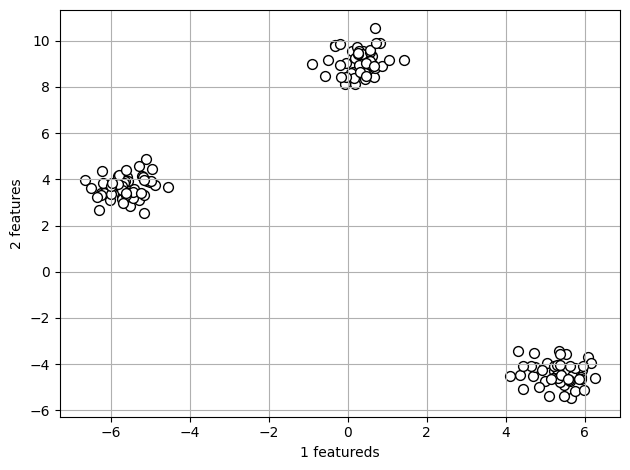

In [2]:
from sklearn.datasets import make_blobs

X, y = make_blobs(n_samples= 150, n_features= 2, shuffle= True, centers = 3, random_state= 23, cluster_std = 0.5)

import matplotlib.pyplot as plt

plt.scatter(X[:, 0], X[:, 1], c = "white", marker = "o", edgecolor="black", s = 50)
plt.xlabel("1 featureds")
plt.ylabel("2 features")
plt.grid()
plt.tight_layout()

In [3]:
from sklearn.cluster import KMeans
km = KMeans(n_clusters= 3,init = 'random', n_init= 10, max_iter= 200, tol= 1e-04, random_state= 12 )
y_km = km.fit_predict(X)

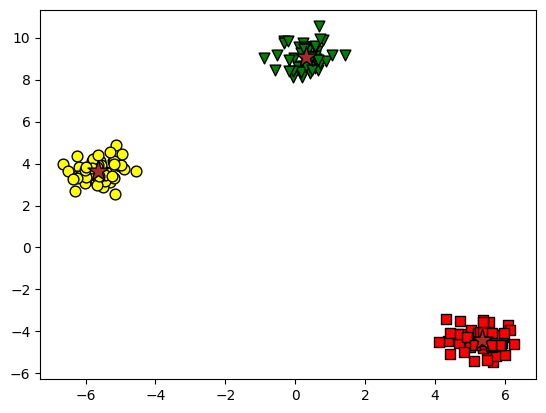

In [4]:
plt.scatter(X[y_km == 0,0], X[y_km == 0,1], label = "cluster 1", s = 60, c = "red", marker = "s", edgecolors= "black")

plt.scatter(X[y_km == 1,0], X[y_km == 1,1], label = "cluster 2", s = 60, c = "yellow", marker = "o", edgecolors= "black")


plt.scatter(X[y_km == 2,0], X[y_km == 2,1], label = "cluster 3", s = 60, c = "green", marker = "v", edgecolors= "black")

plt.scatter(km.cluster_centers_[:, 0], km.cluster_centers_[:, 1], label = "centroids", s = 250, c = "brown", marker = "*", edgecolors= "black")

# Using the elbow method to find the optimal number of clusters
computing within cluster sse

In [5]:
print(f"distortion is the {km.inertia_}")

distortion is the 69.71397043311138


Based on the within-cluster SSE. We can say that if k increases, the distortion will decrease. This is because the examples will be closer to the centroids they are assigned to. 

The idea behind the elbow method is to identify the value of k where the distortion begins to increase most rapidly, which will become clearer if we plot the distortion for different values of k:

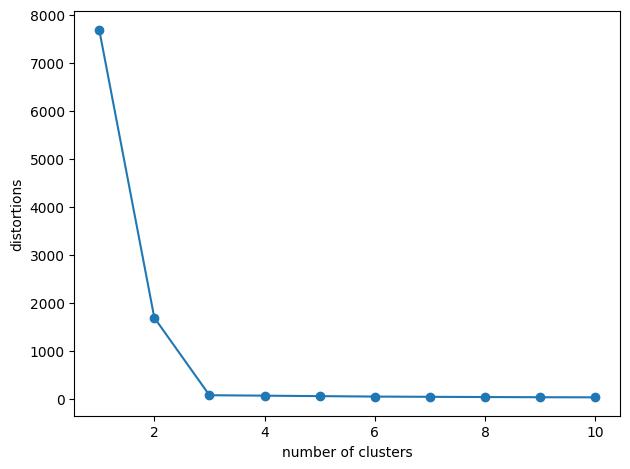

In [6]:
distortions = [] 

for i in range(1,11):
    km = KMeans(n_clusters= i, init = "k-means++", n_init = 10, max_iter = 300,tol = 1e-04, random_state= 23)
    y_km = km.fit_predict(X)
    distortions.append(km.inertia_)
    # note  K-MEANS ++ LEADS TO THE MORE CONSISTENT RESULTS

plt.plot(range(1,11), distortions, marker= 'o')
plt.xlabel("number of clusters")
plt.ylabel("distortions")
plt.tight_layout()
plt.show()

# from above data we can then say that best k is 3 for dataset

# Quantifying the quality of clustering via silhouette plots